# Huber Regression

[![Slides](https://img.shields.io/badge/🦌-ReHLine-blueviolet)](https://rehline-python.readthedocs.io/en/latest/)

The regularized Huber regression solves the following optimization problem:

$$
\min_{\beta \in \mathbb{R}^d}
C \sum_{i=1}^n H_{\tau}(y_i - x_i^\top \beta)
+ \frac{\lambda}{2}\|\beta\|_2^2,
$$

where $H_{\tau}(\cdot)$ is the Huber loss with parameter $\tau$:

$$
H_{\tau}(z)=
\begin{cases}
\frac{z^2}{2}, & |z| \le \tau, \\
\tau\left(|z|-\frac{\tau}{2}\right), & |z| > \tau.
\end{cases}
$$

> **Note.** Since the Huber loss is a plq function, we can optimize it using `rehline.plq_Ridge_Regressor`.
> Moreover, this wrapper adapts the `plqERM_Ridge` into a regressor, compatible with the scikit-learn API.

In [ ]:
## install rehline
%pip install rehline -q

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler

In [3]:
## simulate data
np.random.seed(42)
scaler_huber = StandardScaler()

n, d = 10000, 5
X, y = make_regression(n_samples=n, n_features=d, noise=10.0)
X = scaler_huber.fit_transform(X)
y = y / y.std()

In [4]:
## solve Huber Regression with different `tau` via `plq_Ridge_Regressor`
from rehline import plq_Ridge_Regressor

clf_tau01 = plq_Ridge_Regressor(loss={"name": "huber", "tau": 0.1}, C=10.0 / n)
clf_tau01.fit(X=X, y=y)
clf_tau5 = plq_Ridge_Regressor(loss={"name": "huber", "tau": 5.0}, C=10.0 / n)
clf_tau5.fit(X=X, y=y)

plq_Ridge_Regressor(C=0.001, loss={'name': 'huber', 'tau': 5.0})

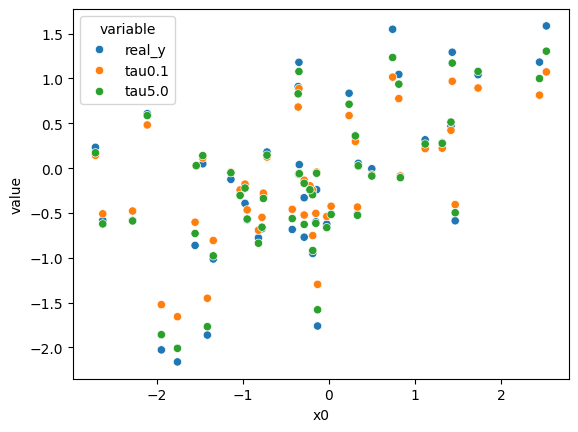

In [5]:
## plot Huber Regression results
warnings.filterwarnings("ignore", "is_categorical_dtype")

n_sample = 50
X_sample, y_sample = X[:n_sample], y[:n_sample]
tau01_sample = clf_tau01.predict(X_sample)
tau5_sample = clf_tau5.predict(X_sample)

df = pd.DataFrame({"x0": X_sample[:, 0], "real_y": y_sample, "tau0.1": tau01_sample, "tau5.0": tau5_sample})
df = df.melt(id_vars="x0")

sns.scatterplot(data=df, x="x0", y="value", hue="variable")
plt.show()

## With Pipeline
`plq_Ridge_Regressor` can be integrated into a scikit-learn Pipeline to streamline preprocessing including scaling.

In [6]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [7]:
## simulate data
np.random.seed(42)

n, d = 10000, 5
X, y = make_regression(n_samples=n, n_features=d, noise=10.0)
y = y / y.std()

In [8]:
## solve Huber Regression with different 'tau' via 'plq_Ridge_Regressor'
from rehline import plq_Ridge_Regressor

pipe_tau01 = Pipeline(
    [("scaler", StandardScaler()), ("reg", plq_Ridge_Regressor(loss={"name": "huber", "tau": 0.1}, C=10.0 / n))]
)
pipe_tau01.fit(X, y)

pipe_tau5 = Pipeline(
    [("scaler", StandardScaler()), ("reg", plq_Ridge_Regressor(loss={"name": "huber", "tau": 5.0}, C=10.0 / n))]
)
pipe_tau5.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('reg',
                 plq_Ridge_Regressor(C=0.001,
                                     loss={'name': 'huber', 'tau': 5.0}))])

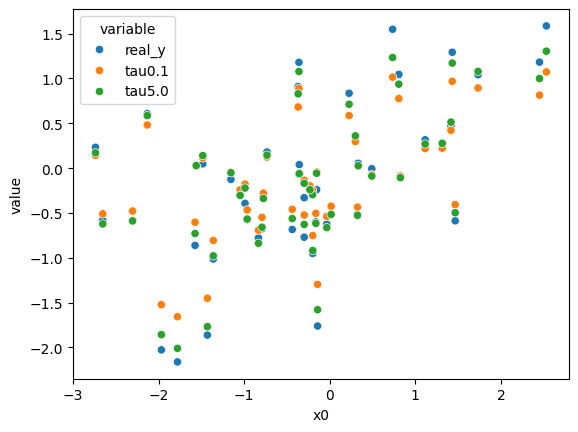

In [9]:
## plot Huber Regression results
warnings.filterwarnings("ignore", "is_categorical_dtype")

n_sample = 50
X_sample, y_sample = X[:n_sample], y[:n_sample]
tau01_sample = pipe_tau01.predict(X_sample)
tau5_sample = pipe_tau5.predict(X_sample)

df = pd.DataFrame({"x0": X_sample[:, 0], "real_y": y_sample, "tau0.1": tau01_sample, "tau5.0": tau5_sample})
df = df.melt(id_vars="x0")

sns.scatterplot(data=df, x="x0", y="value", hue="variable")
plt.show()

## Hyperparameter Tuning with GridSearchCV

Due to its compatibility with the scikit-learn API, `GridSearchCV` can be applied to determine the optimal hyperparameters for the ReHLine model.

In [ ]:
import warnings

from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.model_selection import GridSearchCV

warnings.filterwarnings("ignore")

# Define the parameter grid to search
param_grid = {"reg__C": [1.0 / n, 10.0 / n, 100.0 / n]}

# Use mse to evaluate the performances
mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

# Create the GridSearchCV objects
grid_tau01 = GridSearchCV(pipe_tau01, param_grid, cv=5, scoring=mse_scorer)
grid_tau5 = GridSearchCV(pipe_tau5, param_grid, cv=5, scoring=mse_scorer)

grid_tau01.fit(X, y)
grid_tau5.fit(X, y)

# Print the best parameters and scores
print(f"Best Parameters (tau=0.1): {grid_tau01.best_params_}")
print(f"Best CV Score (tau=0.1): {-grid_tau01.best_score_:.4f}")

print(f"Best Parameters (tau=5.0): {grid_tau5.best_params_}")
print(f"Best CV Score (tau=5.0): {-grid_tau5.best_score_:.4f}")

Best Parameters (tau=0.1): {'reg__C': 0.01}
Best CV Score (tau=0.1): 0.0057
Best Parameters (tau=5.0): {'reg__C': 0.01}
Best CV Score (tau=5.0): 0.0056


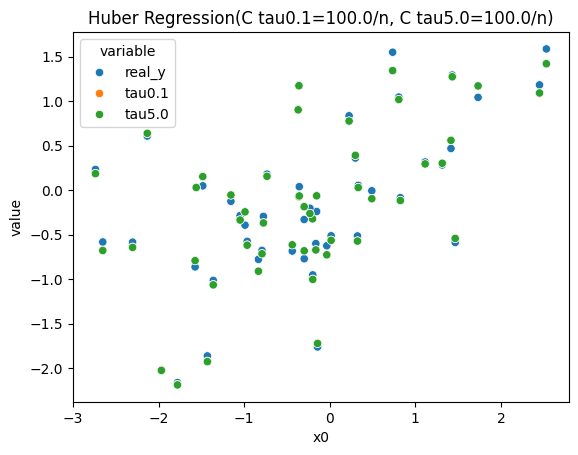

In [11]:
## plot Huber Regression results
warnings.filterwarnings("ignore", "is_categorical_dtype")

n_sample = 50
X_sample, y_sample = X[:n_sample], y[:n_sample]
tau01_sample = grid_tau01.predict(X_sample)
tau5_sample = grid_tau5.predict(X_sample)

df = pd.DataFrame({"x0": X_sample[:, 0], "real_y": y_sample, "tau0.1": tau01_sample, "tau5.0": tau5_sample})
df = df.melt(id_vars="x0")

sns.scatterplot(data=df, x="x0", y="value", hue="variable").set_title(
    "Huber Regression(C tau0.1=100.0/n, C tau5.0=100.0/n)"
)
plt.show()